# Causal Attention: Detect Future Token Leakage

Causal masking is an architectural invariant, not a model-quality metric. Here we verify an original byte-level decoder using input perturbations and a deliberately leaky negative control. [Full training study](https://github.com/zoga228/causal-lm-lab).

AI tools assisted implementation and documentation. This notebook uses random weights for structural verification; trained-model performance is reported separately.

## Decoder implementation

The implementation includes tied input/output embeddings, RoPE, pre-normalization with RMSNorm, SwiGLU feed-forward blocks, and causal scaled dot-product attention. Each position predicts the **next** byte; training targets must be shifted one position. A correct mask alone does not prevent label leakage in data preparation.

In [1]:
"""A byte-level decoder: RoPE, RMSNorm, SwiGLU, tied embeddings, causal SDPA."""
from dataclasses import asdict, dataclass
import json
from pathlib import Path

import torch
from torch import nn
from torch.nn import functional as F
from safetensors.torch import load_file, save_file


@dataclass
class Config:
    vocab_size: int = 256
    width: int = 128
    layers: int = 3
    heads: int = 4
    context: int = 128
    rope: bool = True

    def __post_init__(self):
        if self.width % self.heads or (self.width // self.heads) % 2:
            raise ValueError("Head dimension must be even and divide model width")


class RMSNorm(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(width))

    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + 1e-6) * self.weight


def rotate(x):
    half = x.shape[-1] // 2
    return torch.cat((-x[..., half:], x[..., :half]), dim=-1)


class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.heads = config.heads
        self.dim = config.width // config.heads
        self.rope = config.rope
        self.qkv = nn.Linear(config.width, 3 * config.width, bias=False)
        self.proj = nn.Linear(config.width, config.width, bias=False)
        inv = 1 / (10000 ** (torch.arange(0, self.dim, 2).float() / self.dim))
        self.register_buffer("inv_freq", inv, persistent=False)

    def forward(self, x):
        b, t, w = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        q, k, v = [z.reshape(b, t, self.heads, self.dim).transpose(1, 2) for z in (q, k, v)]
        if self.rope:
            angle = torch.outer(torch.arange(t, device=x.device), self.inv_freq)
            angle = torch.cat((angle, angle), dim=-1)[None, None]
            q = q * angle.cos() + rotate(q) * angle.sin()
            k = k * angle.cos() + rotate(k) * angle.sin()
        attended = F.scaled_dot_product_attention(q, k, v, is_causal=True, dropout_p=0.0)
        return self.proj(attended.transpose(1, 2).contiguous().reshape(b, t, w))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        w = config.width
        hidden = ((int(8 * w / 3) + 31) // 32) * 32
        self.norm1, self.norm2 = RMSNorm(w), RMSNorm(w)
        self.attn = Attention(config)
        self.gate = nn.Linear(w, hidden, bias=False)
        self.up = nn.Linear(w, hidden, bias=False)
        self.down = nn.Linear(hidden, w, bias=False)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        z = self.norm2(x)
        return x + self.down(F.silu(self.gate(z)) * self.up(z))


class ByteLM(nn.Module):
    def __init__(self, config=Config()):
        super().__init__()
        self.config = config
        self.embedding = nn.Embedding(config.vocab_size, config.width)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.layers)])
        self.norm = RMSNorm(config.width)
        self.apply(self._init)

    @staticmethod
    def _init(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, tokens):
        if tokens.ndim != 2 or tokens.shape[1] > self.config.context:
            raise ValueError("Expected [batch, sequence] within configured context")
        x = self.embedding(tokens)
        for block in self.blocks:
            x = block(x)
        return F.linear(self.norm(x), self.embedding.weight)

    @torch.inference_mode()
    def generate(self, prompt, new_bytes=300, temperature=0.8, top_k=40, seed=42):
        if temperature <= 0 or not 1 <= top_k <= self.config.vocab_size:
            raise ValueError("temperature > 0; 1 <= top_k <= vocabulary size")
        self.eval()
        device = next(self.parameters()).device
        raw = list(prompt.encode("utf-8")) or [10]
        tokens = torch.tensor([raw], dtype=torch.long, device=device)
        rng = torch.Generator(device=device).manual_seed(seed)
        for _ in range(new_bytes):
            logits = self(tokens[:, -self.config.context:])[:, -1] / temperature
            cutoff = torch.topk(logits, top_k).values[:, -1:]
            logits = logits.masked_fill(logits < cutoff, float("-inf"))
            token = torch.multinomial(F.softmax(logits, dim=-1), 1, generator=rng)
            tokens = torch.cat((tokens, token), dim=1)
        return bytes(tokens[0].tolist()).decode("utf-8", errors="replace")

    def save_pretrained(self, directory):
        path = Path(directory)
        path.mkdir(parents=True, exist_ok=True)
        (path / "config.json").write_text(json.dumps(asdict(self.config), indent=2))
        (path / "tokenizer.json").write_text(json.dumps({"type": "utf8-bytes", "vocab_size": 256}))
        save_file({k: v.detach().cpu().contiguous() for k, v in self.state_dict().items()}, str(path / "model.safetensors"))

    @classmethod
    def from_pretrained(cls, directory):
        path = Path(directory)
        model = cls(Config(**json.loads((path / "config.json").read_text())))
        model.load_state_dict(load_file(str(path / "model.safetensors")))
        return model.eval()


## Perturbation test and negative control

Changing future inputs must leave all earlier logits unchanged. Using unmasked attention should fail that invariant, ensuring the test can detect an actual leak.

{'prefix_max_difference': 0.0, 'suffix_max_difference': 1.80942964553833}
{'causal_control_difference': 0.0, 'bidirectional_control_difference': 6.416692733764648}


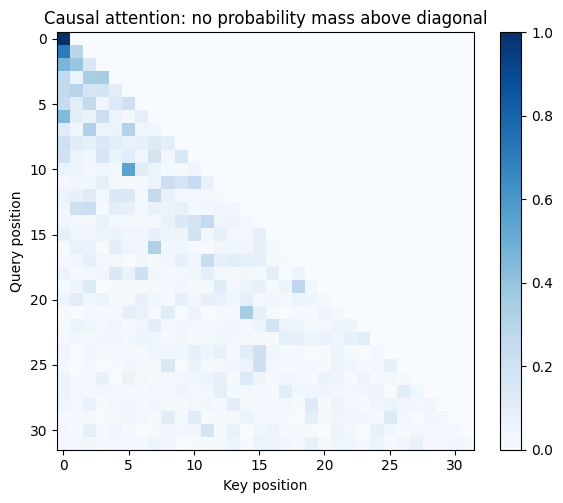

In [2]:
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(2)
torch.manual_seed(42)
model = ByteLM(Config(width=64, layers=2, heads=4, context=32)).eval()
x = torch.randint(0,256,(2,32))
changed = x.clone(); changed[:,16:] = (changed[:,16:]+53)%256
prefix_delta = (model(x)[:,:16]-model(changed)[:,:16]).abs().max().item()
suffix_delta = (model(x)[:,16:]-model(changed)[:,16:]).abs().max().item()
assert prefix_delta < 1e-6 and suffix_delta > 0
print({'prefix_max_difference':prefix_delta,'suffix_max_difference':suffix_delta})
# Deliberately bidirectional negative control: identical weights, different attention mask.
q = torch.randn(1,2,32,16); k = torch.randn_like(q); v = torch.randn_like(q)
v_changed = v.clone(); v_changed[:,:,16:] += 10
causal_delta = (torch.nn.functional.scaled_dot_product_attention(q,k,v,is_causal=True)[:,:,:16]-torch.nn.functional.scaled_dot_product_attention(q,k,v_changed,is_causal=True)[:,:,:16]).abs().max().item()
leaky_delta = (torch.nn.functional.scaled_dot_product_attention(q,k,v)[:,:,:16]-torch.nn.functional.scaled_dot_product_attention(q,k,v_changed)[:,:,:16]).abs().max().item()
assert causal_delta < 1e-6 and leaky_delta > 0
print({'causal_control_difference':causal_delta,'bidirectional_control_difference':leaky_delta})
weights = (q[0,0] @ k[0,0].T / 4).masked_fill(torch.ones(32,32,dtype=torch.bool).triu(1),float('-inf')).softmax(-1)
fig,ax = plt.subplots(figsize=(6,5)); im=ax.imshow(weights.detach().numpy(),cmap='Blues'); fig.colorbar(im,ax=ax)
ax.set(xlabel='Key position',ylabel='Query position',title='Causal attention: no probability mass above diagonal')
fig.tight_layout();plt.show()


## What this proves

The tested computation graph cannot use future inputs at earlier positions, within floating-point tolerance. It does not prove that a trained model generalizes, that data splits are disjoint, or that tokens were shifted correctly. The source repository also tests the gradient path and checkpoint round trip.

References: [PyTorch SDPA](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html), [RoFormer / RoPE](https://arxiv.org/abs/2104.09864).